In [1]:
import vbjax as vb
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time
import sys
import os
import pandas as pd
import seaborn as sns
import tqdm
import jax.example_libraries.optimizers as jopt
from jax.scipy.special import kl_div
import networkx as nx
from copy import deepcopy
from scipy.stats import ks_2samp, entropy

c[vbjax] ███▒▒▒▒▒▒▒ loading
c[vbjax] (ﾉ☉ヮ⚆)ﾉ ⌒*:･ﾟ✧ can haz 14 cores
c[vbjax] ò_ô shtns is not available
c[vbjax] ᕕ(ᐛ)ᕗ ready


In [2]:
cwd = os.getcwd()
functions_path = os.path.join(os.path.dirname(cwd), 'functions')
if functions_path not in sys.path:
    sys.path.append(functions_path)
import site
# Add user site-packages path manually
site_user_base = site.getusersitepackages()
if site_user_base not in sys.path:
    sys.path.append(site_user_base)
import mpr_jax
import FCD_jax
from importlib import reload
mpr_jax=reload(mpr_jax)
FCD_jax=reload(FCD_jax)

In [3]:
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform" 
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"
os.environ["JAX_ENABLE_X64"] = "True"

##  data

SC size 6x6

In [4]:
SC = nx.to_numpy_array(nx.complete_graph(6))
weights=SC
params = {"G": 0.25, 
          "weights": weights,
          "t_end": 300000,
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 1.0, # set to 500 to subsaple BOLD
          "seed":42
          }
def timer(func):
    def wrapper(*args, **kwargs):
        import time
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.2f} seconds")
        return result
    return wrapper

@timer
def wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d
    
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 14.41 seconds


In [5]:
np.shape(bold_d.T) #simulate the full BOLD

(6, 300000)

In [31]:
wwidth = 30  # must be < 60
maxNwindows = 300
olap = 0.94
cut = 10_000 #number of initial time points discarded from the BOLD signal (if BOLD was subsampled, discard 20 only)
tr = 500

FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d[cut::tr].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

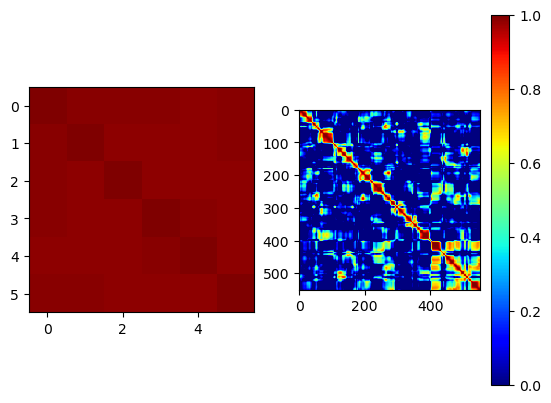

In [32]:
fig, ax = plt.subplots(ncols=2)
ax[0].imshow(FC, vmin=0, vmax=1, cmap='jet') 
im = ax[1].imshow(FCD, vmin=0, vmax=1, cmap='jet') 
fig.colorbar(im) ;

In [17]:
np.shape(FC)

(6, 6)

In [18]:
np.shape(FCD)

(551, 551)

In [19]:
np.shape(u_FC)

(15,)

In [20]:
np.shape(zu_FC)

(15,)

In [21]:
np.shape(u_FCD)

(151525,)

In [22]:
len(bold_d)

300000

## simulator

In [35]:
@timer
def wrapper_with_key(g, key, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    #par["seed"] = seed
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par,key)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [36]:
def run_for_prms_mod(G,key) :
    
    #KEY = jax.random.PRNGKey(0)
    #_, key = jax.random.split(KEY) 
    #bold = run(p, key)
    #seed = int(time.time())

    rv_t, r, v, bold_t, bold_d = wrapper_with_key(G, key, params)
    
    print(G,len(bold_d))
    #sim_fcd = get_fcd(bold_ds)
    sim_fc = jnp.corrcoef(bold_d[cut:].T)
    sim_fcd, FCvec,_ = FCD_jax.extract_FCD(bold_d[cut::tr].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
    
    return bold_d, sim_fc, sim_fcd

In [37]:
def try_loss_mod(prm, key):
    
    losses = {}
    sim_bold, sim_fc, sim_fcd = run_for_prms_mod(prm, key)
    
    losses['mean_fc'] = (jnp.mean(FC) - jnp.mean(jnp.nan_to_num(sim_fc, nan=0.)))**2
    
    u_sim_fc = sim_fc[jnp.triu_indices_from(sim_fc, k=1)]
    zu_sim_fc = (u_sim_fc - jnp.mean(u_sim_fc)) / jnp.std(u_sim_fc)
    r = jnp.corrcoef(zu_sim_fc.flatten(), zu_FC.flatten())[0, 1]
    losses['corr_fc'] = jnp.nan_to_num(r, nan=0.)
    
    u_sim_fcd = sim_fcd[jnp.triu_indices_from(sim_fcd, k=30)]
    losses['var_fcd'] = (jnp.var(u_FCD) - jnp.nan_to_num(jnp.var(u_sim_fcd), nan=0.))**2
    #u_FCD_cut = u_FCD[jnp.triu_indices_from(u_FCD, k=30)]
    #u_sim_fcd = sim_fcd[jnp.triu_indices_from(sim_fcd, k=30)]
    #losses['var_fcd'] = (jnp.var(u_FCD_cut) - jnp.var(u_sim_fcd))**2
    print(np.shape(u_sim_fcd),np.shape(u_FCD))
    kl = kl_div(u_sim_fcd.flatten(), jnp.nan_to_num(u_FCD.flatten(), nan=0.))
    losses['kl_fcd'] = jnp.nan_to_num(jnp.mean(kl), nan=1e6)
    
    losses['mse_fc'] = np.mean((FC - jnp.nan_to_num(sim_fc, nan=0.))**2)
    
    return losses

In [38]:
g_values = np.arange(0., 1.5, 0.05)
loss_sweep_mod = {'mean_fc':[], 'corr_fc':[], 'var_fcd':[], 'kl_fcd':[], 'mse_fc': []}
for g in g_values :
    key = jax.random.PRNGKey(int(time.time()))
    loss = try_loss_mod(g, key)
    for dictkey in loss_sweep_mod.keys() :
        loss_sweep_mod[dictkey].append(loss[dictkey])

wrapper_with_key took 21.36 seconds
0.0 300000
(135981,) (135981,)
wrapper_with_key took 19.17 seconds
0.05 300000
(135981,) (135981,)
wrapper_with_key took 18.79 seconds
0.1 300000
(135981,) (135981,)
wrapper_with_key took 18.82 seconds
0.15000000000000002 300000
(135981,) (135981,)
wrapper_with_key took 19.76 seconds
0.2 300000
(135981,) (135981,)
wrapper_with_key took 19.78 seconds
0.25 300000
(135981,) (135981,)
wrapper_with_key took 23.69 seconds
0.30000000000000004 300000
(135981,) (135981,)
wrapper_with_key took 19.63 seconds
0.35000000000000003 300000
(135981,) (135981,)
wrapper_with_key took 22.42 seconds
0.4 300000
(135981,) (135981,)
wrapper_with_key took 23.11 seconds
0.45 300000
(135981,) (135981,)
wrapper_with_key took 21.64 seconds
0.5 300000
(135981,) (135981,)
wrapper_with_key took 17.29 seconds
0.55 300000
(135981,) (135981,)
wrapper_with_key took 21.21 seconds
0.6000000000000001 300000
(135981,) (135981,)
wrapper_with_key took 18.13 seconds
0.65 300000
(135981,) (135

In [39]:
for key in loss_sweep_mod.keys() :
    loss_sweep_mod[key] = np.array(loss_sweep_mod[key])

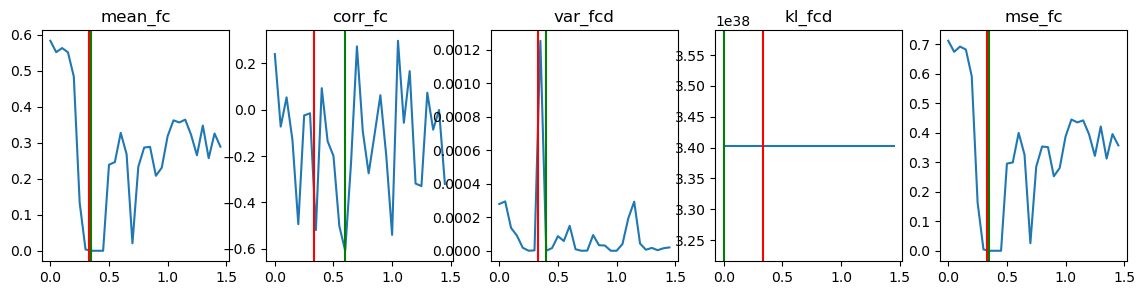

In [40]:
fig, ax = plt.subplots(ncols=len(loss_sweep_mod), figsize=(14, 3))
for i, (k,v) in enumerate(loss_sweep_mod.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

## add KL and KS losses for both FC and FCD

In [41]:
def try_loss_mod_extended(prm, FC_obs, FCD_obs, FC_obs_flat, FCD_obs_flat, key, wwidth=30, olap=0.94, bins=50):
    """
    Compute multiple loss components between simulated and observed FC/FCD.
    """

    losses = {}
    sim_bold, sim_fc, sim_fcd = run_for_prms_mod(prm, key)

    # --- 1. Static FC measures ---
    sim_fc_np = np.array(sim_fc)
    obs_fc_np = np.array(FC_obs)
    
    # mean FC difference
    losses["mean_fc"] = float((np.mean(obs_fc_np) - np.mean(sim_fc_np)) ** 2)
    
    # upper triangle indices
    
    u_sim_fc = sim_fc[jnp.triu_indices_from(sim_fc, k=1)]
    zu_sim_fc = (u_sim_fc - jnp.mean(u_sim_fc)) / jnp.std(u_sim_fc)
    r = jnp.corrcoef(zu_sim_fc.flatten(), zu_FC.flatten())[0, 1]
    
    iu = np.triu_indices_from(sim_fc_np, k=1)
    u_sim_fc = sim_fc_np[iu]
    u_obs_fc = obs_fc_np[iu]
    
    # correlation of FC patterns
    zu_sim_fc = (u_sim_fc - np.mean(u_sim_fc)) / (np.std(u_sim_fc) + 1e-8)
    zu_obs_fc = (u_obs_fc - np.mean(u_obs_fc)) / (np.std(u_obs_fc) + 1e-8)
    r = np.corrcoef(zu_sim_fc, zu_obs_fc)[0, 1]
    losses["corr_fc"] = float(np.nan_to_num(r, nan=0.0))
    
    # MSE of FC
    losses["mse_fc"] = float(np.mean((obs_fc_np - sim_fc_np) ** 2))

    # --- 2. FC distributional measures ---
    sim_fc_flat = np.array(sim_fc_np).ravel()
    obs_fc_flat = np.array(FC_obs_flat)

    # KS distance
    losses["ks_fc"] = float(ks_2samp(obs_fc_flat, sim_fc_flat)[0])

    # histogram-based KL divergence
    eps = 1e-8
    p_hist, edges = np.histogram(obs_fc_flat, bins=bins, density=True)
    q_hist, _ = np.histogram(sim_fc_flat, bins=edges, density=True)
    p = (p_hist + eps) / (p_hist + eps).sum()
    q = (q_hist + eps) / (q_hist + eps).sum()
    losses["kl_fc_hist"] = float(entropy(p, q))

    # --- 3. Dynamic FCD measures ---
    sim_fcd_np = np.array(sim_fcd)
    obs_fcd_np = np.array(FCD_obs)

    # same diagonal skip for both
    iu_fcd = np.triu_indices_from(sim_fcd_np, k=30)
    u_sim_fcd = sim_fcd_np[iu_fcd]
    u_obs_fcd = obs_fcd_np[iu_fcd]

    # variance difference
    losses["var_fcd"] = float((np.var(u_obs_fcd) - np.var(u_sim_fcd)) ** 2)

    # KS for FCD
    #losses["ks_fcd"] = float(ks_2samp(FCD_obs_flat, np.ravel(sim_fcd_np))[0])

    # histogram-based KL for FCD
    #p_hist, edges = np.histogram(FCD_obs_flat, bins=bins, density=True)
    #q_hist, _ = np.histogram(np.ravel(sim_fcd_np), bins=edges, density=True)


    losses["ks_fcd"] = float(ks_2samp(u_obs_fcd, u_sim_fcd)[0])
    
    # Histogram-based KL for FCD (only on selected upper triangle values)
    eps = 1e-8
    p_hist, edges = np.histogram(u_obs_fcd, bins=bins, density=True)
    q_hist, _ = np.histogram(u_sim_fcd, bins=edges, density=True)

    

    p = (p_hist + eps) / (p_hist + eps).sum()
    q = (q_hist + eps) / (q_hist + eps).sum()
    losses["kl_fcd_hist"] = float(entropy(p, q))

    return losses


In [42]:
g_values = np.arange(0., 1.5, 0.05)
loss_sweep_mod_extended = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    key = jax.random.PRNGKey(int(time.time()))
    loss = try_loss_mod_extended(g, FC, FCD, u_FC, u_FCD, key)
    for key in loss_sweep_mod_extended.keys() :
        loss_sweep_mod_extended[key].append(loss[key])

wrapper_with_key took 21.25 seconds
0.0 300000


/home/monica/anaconda3/envs/myenv/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


wrapper_with_key took 22.49 seconds
0.05 300000
wrapper_with_key took 21.36 seconds
0.1 300000
wrapper_with_key took 17.95 seconds
0.15000000000000002 300000
wrapper_with_key took 18.74 seconds
0.2 300000
wrapper_with_key took 19.47 seconds
0.25 300000
wrapper_with_key took 20.93 seconds
0.30000000000000004 300000
wrapper_with_key took 18.26 seconds
0.35000000000000003 300000
wrapper_with_key took 18.03 seconds
0.4 300000
wrapper_with_key took 17.61 seconds
0.45 300000
wrapper_with_key took 19.13 seconds
0.5 300000
wrapper_with_key took 19.20 seconds
0.55 300000
wrapper_with_key took 18.79 seconds
0.6000000000000001 300000
wrapper_with_key took 19.56 seconds
0.65 300000
wrapper_with_key took 19.76 seconds
0.7000000000000001 300000
wrapper_with_key took 18.84 seconds
0.75 300000
wrapper_with_key took 20.92 seconds
0.8 300000
wrapper_with_key took 20.74 seconds
0.8500000000000001 300000
wrapper_with_key took 21.67 seconds
0.9 300000
wrapper_with_key took 20.11 seconds
0.9500000000000001 

In [43]:
for key in loss_sweep_mod_extended.keys() :
    loss_sweep_mod_extended[key] = np.array(loss_sweep_mod_extended[key])

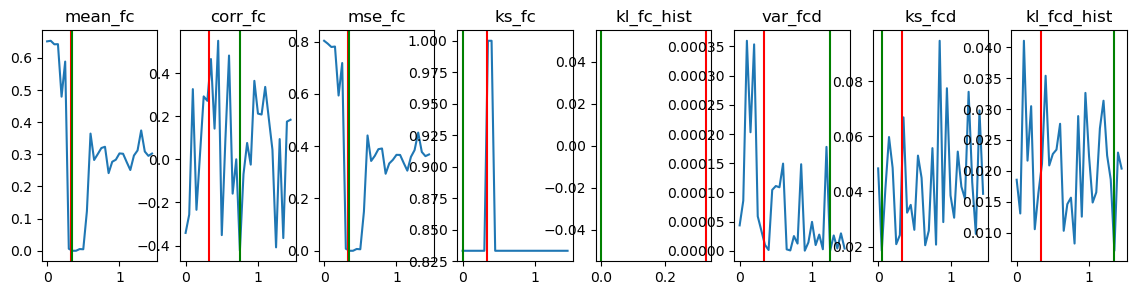

In [44]:
fig, ax = plt.subplots(ncols=len(loss_sweep_mod_extended), figsize=(14, 3))
for i, (k,v) in enumerate(loss_sweep_mod_extended.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

kl_fc is not working for the 6x6 case because FC is also 6x6 (36 elements) and an histogram of 50 bins is almost empty so i get a lot of NaNs

it will be better with bigger SC matrix (alternative for the 6x6 case is to not making the histogram but FC_flat is not a distribution itself so i is not okay)

## take average on multiple simulations in order to smooth loss

In [45]:
import jax
import jax.numpy as jnp
import numpy as np
from scipy.stats import ks_2samp, entropy
import time

def try_loss_mod_per_key(prm, FC_obs, FCD_obs, FC_obs_flat, FCD_obs_flat, 
                         n_keys=10, wwidth=30, olap=0.94, bins=50):
    """
    Compute multiple loss components between simulated and observed FC/FCD,
    evaluating each random seed separately and then aggregating losses.
    """

    base_key = jax.random.PRNGKey(int(time.time()))
    #base_key = jax.random.PRNGKey(0)
    keys = jax.random.split(base_key, n_keys)

    def run_with_key(key):
        sim_bold, sim_fc, sim_fcd = run_for_prms_mod(prm, key)
        return sim_fc, sim_fcd

    # Vectorized run for all keys
    fcs, fcds = jax.vmap(run_with_key)(keys)

    # Convert to numpy for analysis
    fcs_np = np.array(fcs)
    fcds_np = np.array(fcds)

    obs_fc_np = np.array(FC_obs)
    obs_fc_flat_np = np.array(FC_obs_flat)
    obs_fcd_np = np.array(FCD_obs)
    obs_fcd_flat_np = np.array(FCD_obs_flat)

    losses = {
        "mean_fc": 0.0,
        "corr_fc": 0.0,
        "mse_fc": 0.0,
        "ks_fc": 0.0,
        "kl_fc_hist": 0.0,
        "var_fcd": 0.0,
        "ks_fcd": 0.0,
        "kl_fcd_hist": 0.0,
    }

    eps = 1e-8

    # Compute losses separately for each simulation, then sum
    for sim_fc, sim_fcd in zip(fcs_np, fcds_np):
        # --- FC losses ---
        losses["mean_fc"] += (np.mean(obs_fc_np) - np.mean(sim_fc)) ** 2

        iu = np.triu_indices_from(sim_fc, k=1)
        u_sim_fc = sim_fc[iu]
        u_obs_fc = obs_fc_np[iu]
        zu_sim_fc = (u_sim_fc - np.mean(u_sim_fc)) / (np.std(u_sim_fc) + eps)
        zu_obs_fc = (u_obs_fc - np.mean(u_obs_fc)) / (np.std(u_obs_fc) + eps)
        r = np.corrcoef(zu_sim_fc, zu_obs_fc)[0, 1]
        losses["corr_fc"] += np.nan_to_num(r, nan=0.0)

        losses["mse_fc"] += np.mean((obs_fc_np - sim_fc) ** 2)

        # --- FC distributional metrics ---
        sim_fc_flat = sim_fc.flatten()
        losses["ks_fc"] += ks_2samp(obs_fc_flat_np, sim_fc_flat)[0]

        p_hist, edges = np.histogram(obs_fc_flat_np, bins=bins, density=True)
        q_hist, _ = np.histogram(sim_fc_flat, bins=edges, density=True)
        p = (p_hist + eps) / (p_hist + eps).sum()
        q = (q_hist + eps) / (q_hist + eps).sum()
        losses["kl_fc_hist"] += entropy(p, q)

        # --- FCD losses ---
        iu_fcd = np.triu_indices_from(sim_fcd, k=30)
        u_sim_fcd = sim_fcd[iu_fcd]
        u_obs_fcd = obs_fcd_np[iu_fcd]

        losses["var_fcd"] += (np.var(u_obs_fcd) - np.var(u_sim_fcd)) ** 2
        losses["ks_fcd"] += ks_2samp(u_obs_fcd, u_sim_fcd)[0]

        p_hist, edges = np.histogram(u_obs_fcd, bins=bins, density=True)
        q_hist, _ = np.histogram(u_sim_fcd, bins=edges, density=True)
        p = (p_hist + eps) / (p_hist + eps).sum()
        q = (q_hist + eps) / (q_hist + eps).sum()
        losses["kl_fcd_hist"] += entropy(p, q)

        #print((np.mean(obs_fc_np) - np.mean(sim_fc)) ** 2, np.corrcoef(zu_sim_fc, zu_obs_fc)[0, 1], np.mean((obs_fc_np - sim_fc) ** 2))
    # Average or keep sum 
    #for k in losses:
    #    losses[k] = float(losses[k] / n_keys)  

    return losses


In [46]:
g_values = np.arange(0., 1.5, 0.05)
losses = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss = try_loss_mod_per_key(g, FC, FCD, u_FC, u_FCD)
    for key in losses.keys() :
        losses[key].append(loss[key])

wrapper_with_key took 74.40 seconds
0.0 300000
wrapper_with_key took 59.67 seconds
0.05 300000
wrapper_with_key took 59.34 seconds
0.1 300000
wrapper_with_key took 57.50 seconds
0.15000000000000002 300000
wrapper_with_key took 58.71 seconds
0.2 300000
wrapper_with_key took 55.90 seconds
0.25 300000
wrapper_with_key took 60.02 seconds
0.30000000000000004 300000
wrapper_with_key took 58.09 seconds
0.35000000000000003 300000
wrapper_with_key took 71.59 seconds
0.4 300000
wrapper_with_key took 61.02 seconds
0.45 300000
wrapper_with_key took 60.75 seconds
0.5 300000
wrapper_with_key took 59.64 seconds
0.55 300000
wrapper_with_key took 62.20 seconds
0.6000000000000001 300000
wrapper_with_key took 59.73 seconds
0.65 300000
wrapper_with_key took 61.65 seconds
0.7000000000000001 300000
wrapper_with_key took 70.46 seconds
0.75 300000
wrapper_with_key took 61.11 seconds
0.8 300000
wrapper_with_key took 64.56 seconds
0.8500000000000001 300000
wrapper_with_key took 66.67 seconds
0.9 300000
wrapper_

In [47]:
for key in losses.keys() :
    losses[key] = np.array(losses[key])

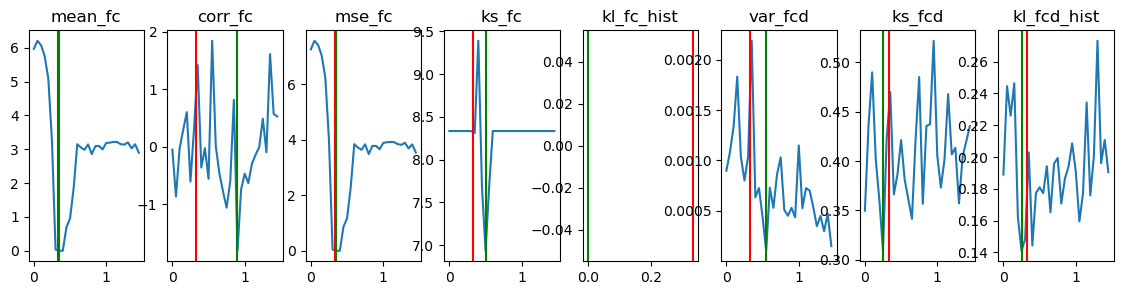

In [48]:
fig, ax = plt.subplots(ncols=len(losses), figsize=(14, 3))
for i, (k,v) in enumerate(losses.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### batching simulations

In [58]:
## is it useful to speed up computation?

## infer different values of g

In [59]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.0, params)

wrapper took 14.99 seconds


In [62]:
wwidth = 30  # must be < 60
maxNwindows = 300
olap = 0.94
cut = 10_000 #number of initial time points discarded from the BOLD signal (if BOLD was subsampled, discard 20 only)
tr = 500

FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d[cut::tr].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

In [63]:
g_values = np.arange(0., 1.5, 0.05)
losses = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss = try_loss_mod_per_key(g, FC, FCD, u_FC, u_FCD)
    for key in losses.keys() :
        losses[key].append(loss[key])

wrapper_with_key took 56.67 seconds
0.0 300000
wrapper_with_key took 64.33 seconds
0.05 300000
wrapper_with_key took 59.37 seconds
0.1 300000
wrapper_with_key took 56.71 seconds
0.15000000000000002 300000
wrapper_with_key took 59.73 seconds
0.2 300000
wrapper_with_key took 62.67 seconds
0.25 300000


/home/monica/anaconda3/envs/myenv/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


wrapper_with_key took 69.36 seconds
0.30000000000000004 300000
wrapper_with_key took 67.19 seconds
0.35000000000000003 300000
wrapper_with_key took 66.12 seconds
0.4 300000


KeyboardInterrupt: 

In [ ]:
for key in losses.keys() :
    losses[key] = np.array(losses[key])

In [ ]:
fig, ax = plt.subplots(ncols=len(losses), figsize=(14, 3))
for i, (k,v) in enumerate(losses.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

In [ ]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.5, params)

In [ ]:
wwidth = 30  # must be < 60
maxNwindows = 300
olap = 0.94
cut = 10_000 #number of initial time points discarded from the BOLD signal (if BOLD was subsampled, discard 20 only)
tr = 500

FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d[cut::tr].T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

In [ ]:
g_values = np.arange(0., 1.5, 0.05)
losses = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss = try_loss_mod_per_key(g, FC, FCD, u_FC, u_FCD)
    for key in losses.keys() :
        losses[key].append(loss[key])

In [ ]:
for key in losses.keys() :
    losses[key] = np.array(losses[key])

In [ ]:
fig, ax = plt.subplots(ncols=len(losses), figsize=(14, 3))
for i, (k,v) in enumerate(losses.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### try to jit the run function instead of the integrate only in order to see if there is a speed up (spoiler there's not)

In [107]:
parameters = params
parameters['G'] = 0.33
parameters

{'G': 0.33,
 'weights': Array([[0., 1., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1.],
        [1., 1., 0., 1., 1., 1.],
        [1., 1., 1., 0., 1., 1.],
        [1., 1., 1., 1., 0., 1.],
        [1., 1., 1., 1., 1., 0.]], dtype=float32),
 't_end': 300000,
 'dt': 0.01,
 'eta': Array([-4.6], dtype=float32),
 'rv_decimate': 10,
 'noise_amp': 0.037,
 'tr': 500.0,
 'seed': 42}

In [112]:
# keep your class for setup
KEY = jax.random.PRNGKey(0)
mpr = mpr_jax.MPR_sde.create(params, KEY)
P, B, key, x0 = mpr.P, mpr.B, mpr.key, mpr.with_initial_state().initial_state

In [113]:
P=P.replace(initial_state=x0)
P

ParMPR(G=0.33, dt=0.01, J=14.5, eta=Array([-4.6], dtype=float32), tau=1.0, weights=Array([[0., 1., 1., 1., 1., 1.],
       [1., 0., 1., 1., 1., 1.],
       [1., 1., 0., 1., 1., 1.],
       [1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 0.]], dtype=float32), delta=0.7, t_init=0.0, t_cut=0.0, t_end=300000, nn=6, method='default', seed=42, initial_state=Array([ 0.8682486 ,  0.33089608,  0.15609509,  0.5110325 ,  0.2359348 ,
        0.9191589 , -1.6366563 , -0.55116796,  0.48642778, -1.3662944 ,
       -0.12354469, -1.2746215 ], dtype=float32), noise_amp=0.037, sigma_r=Array(0.02720294, dtype=float32, weak_type=True), sigma_v=Array(0.03847077, dtype=float32, weak_type=True), iapp=0.0, output='output', RECORD_RV=True, RECORD_BOLD=True, rv_decimate=10, tr=500.0)

In [150]:
from functools import partial

#@partial(jax.jit, static_argnames=["nt", "record_bold", "rv_decimate", "bold_decimate"])
def run_jitted(P, B, key, x0, nt, record_bold=True, rv_decimate=10, bold_decimate=1):
    nn = P.nn
    #P = P.replace(initial_state=x0)

    result = mpr_jax.integrate_jitted(
        nn,
        P,
        B,
        key=key,
        record_rv=False,
        record_bold=record_bold,
        nt=nt,
        rv_decimate=1,
        bold_decimate=bold_decimate
    )
    return result

In [151]:
x0 = P.initial_state
P_fixed = mpr.P.replace(initial_state=x0)
nt = int(P_fixed.t_end / P_fixed.dt)
rv_decimate = int(P_fixed.rv_decimate)
bold_decimate = int(np.round(mpr.P.tr / (P_fixed.dt * rv_decimate)))

result = run_jitted(P_fixed, mpr.B, mpr.key, x0, nt, True, rv_decimate, bold_decimate=1)


In [147]:
result = mpr_jax.integrate_jitted(
    P.nn,
    P,
    B,
    key=key,
    record_rv=False,
    record_bold=True,
    nt=nt,
    rv_decimate=rv_decimate,
    bold_decimate=bold_decimate
)

For now loss = (mean(true_fc) - mean(simulated_fc))^2.
Same issues with other losses, combination of losses etc

In [269]:
def loss(prm) :
    sim_bold, sim_fc, sim_fcd = run_for_prms(prm)
    return (jnp.mean(FC) - jnp.mean(jnp.nan_to_num(sim_fc, nan=0.)))**2

with learning rate "too small":

initial loss 0.04227746


loss 0.048: 100%|█████████████████████████████| 100/100 [13:18<00:00,  7.98s/it]


Text(0.5, 1.0, 'trace loss')

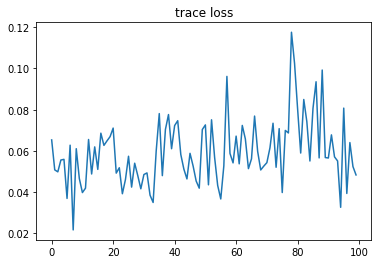

In [278]:
params = 0.85
print('initial loss', loss(params))  # good to check this is finite!

# choose learning rate / optimizer step size
lr = 0.001

# create the optimizer (it returns 3 functions)
opt_init, opt_step, opt_get = jopt.adam(lr)

# create optimizer state
opt = opt_init(params)

# compile the loss function w/ gradients
vgloss = jax.jit(jax.value_and_grad(loss))

# do some steps
trace_loss = []
trace_grad = []
trace_params = []
for i in (pbar := tqdm.trange(100)):
    v, g = vgloss(opt_get(opt))
    trace_loss.append(v)
    trace_grad.append(g)
    g = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1, 1), g) # clip stablizes optimization
    opt = opt_step(i, g, opt)
    trace_params.append(opt_get(opt))
    pbar.set_description(f'loss {v:0.3f}')
    
params_final = opt_get(opt)
plt.figure(); plt.plot(trace_loss); plt.title('trace loss')

In [279]:
print(np.array(trace_params[:5]), '\n...\n', np.array(trace_params[-5:]))

[0.84900004 0.84800005 0.8477381  0.84784305 0.8481666 ] 
...
 [0.85230213 0.85193855 0.85151136 0.85122687 0.8510708 ]


In [280]:
print(np.array(trace_grad[:5]), '\n...\n', np.array(trace_grad[-5:]))

[ 7.0553924e+14  7.6258320e+20 -1.4664318e+13 -5.2071273e+17
 -7.4946142e+10] 
...
 [ 3.01519520e+08 -1.97725655e+22  1.85535545e+11 -3.55219255e+13
 -1.02916915e+11]


In [281]:
np.array(trace_params)[np.argmin(trace_loss)]

0.8487935

initial loss 0.0776693


loss 0.126: 100%|█████████████████████████████| 100/100 [13:18<00:00,  7.99s/it]


Text(0.5, 1.0, 'trace loss')

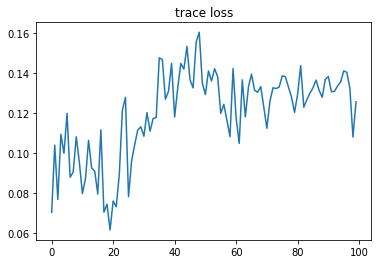

In [95]:
params = 0.8
print('initial loss', loss(params))  # good to check this is finite!

# choose learning rate / optimizer step size
lr = 0.01

# create the optimizer (it returns 3 functions)
opt_init, opt_step, opt_get = jopt.adam(lr)

# create optimizer state
opt = opt_init(params)

# compile the loss function w/ gradients
vgloss = jax.jit(jax.value_and_grad(loss))

# do some steps
trace_loss = []
trace_grad = []
trace_params = []
for i in (pbar := tqdm.trange(100)):
    v, g = vgloss(opt_get(opt))
    trace_loss.append(v)
    trace_grad.append(g)
    g = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1, 1), g) # clip stablizes optimization
    opt = opt_step(i, g, opt)
    trace_params.append(opt_get(opt))
    pbar.set_description(f'loss {v:0.3f}')
    
params_final = opt_get(opt)
plt.figure(); plt.plot(trace_loss); plt.title('trace loss')

wih high learning rate

initial loss 0.042178076


loss 0.011: 100%|█████████████████████████████| 100/100 [13:12<00:00,  7.92s/it]


Text(0.5, 1.0, 'trace loss')

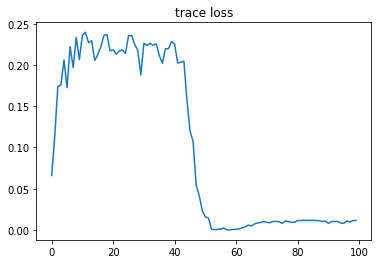

In [270]:
params = 0.85
print('initial loss', loss(params))  # good to check this is finite!

# choose learning rate / optimizer step size
lr = 0.1

# create the optimizer (it returns 3 functions)
opt_init, opt_step, opt_get = jopt.adam(lr)

# create optimizer state
opt = opt_init(params)

# compile the loss function w/ gradients
vgloss = jax.jit(jax.value_and_grad(loss))

# do some steps
trace_loss = []
trace_grad = []
trace_params = []
for i in (pbar := tqdm.trange(100)):
    v, g = vgloss(opt_get(opt))
    trace_loss.append(v)
    trace_grad.append(g)
    g = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1, 1), g) # clip stablizes optimization
    opt = opt_step(i, g, opt)
    trace_params.append(opt_get(opt))
    pbar.set_description(f'loss {v:0.3f}')
    
params_final = opt_get(opt)
plt.figure(); plt.plot(trace_loss); plt.title('trace loss')

In [274]:
print(np.array(trace_params[:5]), '\n...\n', np.array(trace_params[-5:]))

[0.7500007  0.6500017  0.6238028  0.63429993 0.61781454] 
...
 [-0.722563   -0.7344046  -0.73643756 -0.7370563  -0.7367012 ]


In [275]:
print(np.array(trace_grad[:5]), '\n...\n', np.array(trace_grad[-5:]))

[ 7.0195201e+14  6.1415950e+05 -1.3325339e+04 -2.1473061e+04
  2.3568242e+04] 
...
 [ 0.04366665  0.15118557 -0.63979524 -0.08991866 -0.06705152]


In [277]:
np.array(trace_params)[np.argmin(trace_loss)]

-0.52280134

When init close to solution: fails (NaN gradients and parameters) when approaching solution ? 

Note that the true value of G (which is optimal for maximizing FCD) places the system close to NaN outputs, when G is increased above this value it can produce Nans. 

initial loss 0.0045287795


loss 0.476: 100%|███████████████████████████████| 10/10 [01:27<00:00,  8.72s/it]


Text(0.5, 1.0, 'trace loss')

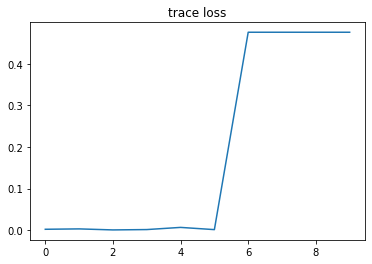

In [177]:
params = 1.
print('initial loss', loss(params))  # good to check this is finite!

# choose learning rate / optimizer step size
lr = 0.01

# create the optimizer (it returns 3 functions)
opt_init, opt_step, opt_get = jopt.adam(lr)

# create optimizer state
opt = opt_init(params)

# compile the loss function w/ gradients
vgloss = jax.jit(jax.value_and_grad(loss))

# do some steps
trace_loss = []
trace_grad = []
trace_params = []
for i in (pbar := tqdm.trange(10)):
    v, g = vgloss(opt_get(opt))
    trace_loss.append(v)
    trace_grad.append(g)
    g = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1, 1), g) # clip stablizes optimization
    opt = opt_step(i, g, opt)
    trace_params.append(opt_get(opt))
    pbar.set_description(f'loss {v:0.3f}')
    
params_final = opt_get(opt)
plt.figure(); plt.plot(trace_loss); plt.title('trace loss')

In [178]:
trace_params

[Array(1.01, dtype=float32),
 Array(1.0199999, dtype=float32),
 Array(1.0226197, dtype=float32),
 Array(1.0273856, dtype=float32),
 Array(1.0334296, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32)]

In [179]:
trace_grad

[Array(-3.6905456e+26, dtype=float32, weak_type=True),
 Array(-7.953938e+31, dtype=float32),
 Array(7.9022427e+34, dtype=float32),
 Array(-4.589451e+33, dtype=float32),
 Array(-1.3101528e+33, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32)]

A close-up on kl, not usable as it is for now

In [247]:
def loss_kl_fcd(prm):
    
    sim_bold, sim_fc, sim_fcd = run_for_prms(prm)
    u_sim_fcd = sim_fcd[jnp.triu_indices_from(sim_fcd, k=30)]
    kl = kl_div(u_sim_fcd.flatten(), jnp.nan_to_num(u_FCD.flatten(), nan=0.))
    return jnp.nan_to_num(jnp.mean(kl), nan=100.)

In [252]:
trace_loss = []
for g in np.arange(0.95, 1.2, 0.01) :
    trace_loss.append(loss_kl_fcd(g))
trace_loss = np.array(trace_loss)

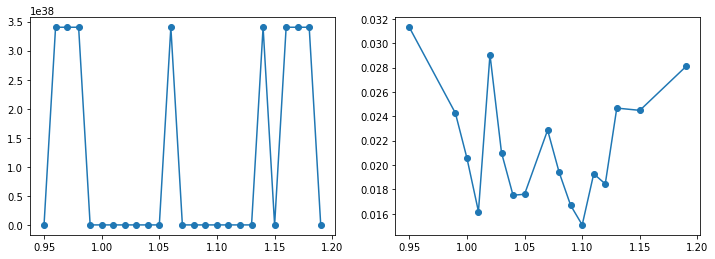

In [265]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
ax[0].plot(np.arange(0.95, 1.2, 0.01), trace_loss, '-o')
ax[1].plot(np.arange(0.95, 1.2, 0.01)[np.argwhere(trace_loss <= 10**6)], 
           trace_loss[np.argwhere(trace_loss <= 10**6)], '-o') ;

initial loss 0.022862433


loss 100.000: 100%|█████████████████████████████| 10/10 [01:27<00:00,  8.71s/it]


Text(0.5, 1.0, 'trace loss')

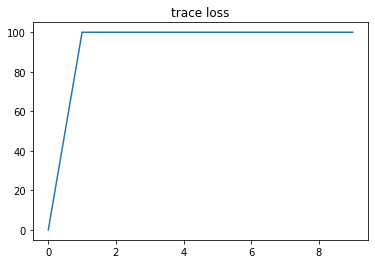

In [267]:
params = 1.07
print('initial loss', loss_kl_fcd(params))  # good to check this is finite!

# choose learning rate / optimizer step size
lr = 0.01

# create the optimizer (it returns 3 functions)
opt_init, opt_step, opt_get = jopt.adam(lr)

# create optimizer state
opt = opt_init(params)

# compile the loss function w/ gradients
vgloss = jax.jit(jax.value_and_grad(loss_kl_fcd))

# do some steps
trace_loss = []
trace_grad = []
trace_params = []
for i in (pbar := tqdm.trange(10)):
    v, g = vgloss(opt_get(opt))
    trace_loss.append(v)
    trace_grad.append(g)
    g = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1, 1), g) # clip stablizes optimization
    opt = opt_step(i, g, opt)
    trace_params.append(opt_get(opt))
    pbar.set_description(f'loss {v:0.3f}')
    
params_final = opt_get(opt)
plt.figure(); plt.plot(trace_loss); plt.title('trace loss')

In [268]:
trace_params

[Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32)]